In [1]:
import torch

from utils import extract_coordinates
from viz_utils import plot_simulation, plot_random_samples, plot_loss
from data_utils import generate_relative_polar_position_dataset

from simulation import RandomWalkMotionModel, SquareArena, SimulationController
from custom_loss import NormalizedMSELoss
from model_builder import SimpleRNN

In [2]:
seed = 42
theta_sigma = 0.1
v_max = 1

motion_model = RandomWalkMotionModel(seed, theta_sigma, v_max)

In [3]:
arena_size = 10
eps = 1e-6

motion_arena = SquareArena(arena_size, eps)

In [4]:
controller = SimulationController(motion_model, motion_arena)

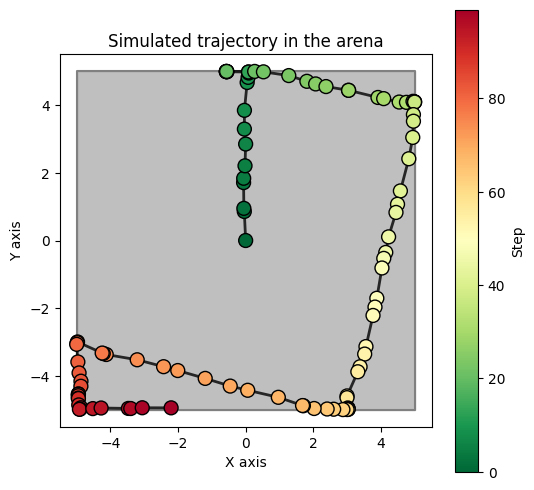

In [5]:
simulation = extract_coordinates(
    controller.generate(
        num_steps=100,
        )
)

plot_simulation(
    data=simulation,
    arena=motion_arena,
    figsize=(6, 6),
    arena_color="grey",
    arena_fill_alpha=0.5,
    point_cmap="RdYlGn_r",
    point_color="black",
    trajectory_color="black",
    show_trajectory=True,
    point_size=100,
    point_edge_color="black",
    trajectory_line_width=2,
    show_colorbar=True
)

In [6]:
num_samples = 30
num_steps = 10

features, _, positions = generate_relative_polar_position_dataset(
    controller, num_samples, num_steps
)

features.shape, positions.shape

(torch.Size([30, 10, 2]), torch.Size([30, 10, 2]))

In [7]:
sample_id = 1
steps = 5

print(f"First {steps} steps for sample number {sample_id}.")
print(f"Features:\n{features[sample_id][:steps]}")
print(f"Angles:\n{positions[sample_id][:steps, 0]}")
print(f"Distances:\n{positions[sample_id][:steps, 1]}")

First 5 steps for sample number 1.
Features:
tensor([[0.0000, 0.0000],
        [0.1969, 0.8123],
        [0.1012, 0.4684],
        [0.0856, 0.2299],
        [0.0342, 0.6428]])
Angles:
tensor([0.0000, 0.1969, 0.1619, 0.1503, 0.1157])
Distances:
tensor([0.0000, 0.8123, 1.2793, 1.5087, 2.1485])


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
num_inputs = 2
num_outputs = 2
hidden_size = 32
num_layers = 2
batch_first = True

model = SimpleRNN(
    num_inputs, num_outputs, hidden_size, num_layers, batch_first
)

In [10]:
num_samples = 1024
num_steps = 25

num_epochs = 1000

In [11]:
learning_rate = 0.001
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate
)

In [12]:
loss_fn = NormalizedMSELoss(
    arena_size=arena_size,
    angle_weight=0.5,
    distance_weight=0.5,
    reduction="mean",
)

In [13]:
torch.manual_seed(seed)

losses = []

model.to(device)
model.train()

for epoch in range(1, num_epochs + 1):
    features, _, positions = generate_relative_polar_position_dataset(
        controller, num_samples, num_steps
    )

    inputs = features.to(device)
    targets = positions.to(device)

    predictions = model(inputs)
    loss = loss_fn(predictions, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    print(f"Epoch: {epoch} | Loss: {loss.item():.6f}")

Epoch: 1 | Loss: 0.367143
Epoch: 2 | Loss: 0.357361
Epoch: 3 | Loss: 0.355863
Epoch: 4 | Loss: 0.343383
Epoch: 5 | Loss: 0.334605
Epoch: 6 | Loss: 0.330227
Epoch: 7 | Loss: 0.319769
Epoch: 8 | Loss: 0.317315
Epoch: 9 | Loss: 0.308312
Epoch: 10 | Loss: 0.306030
Epoch: 11 | Loss: 0.296438
Epoch: 12 | Loss: 0.280949
Epoch: 13 | Loss: 0.277560
Epoch: 14 | Loss: 0.265743
Epoch: 15 | Loss: 0.260001
Epoch: 16 | Loss: 0.250432
Epoch: 17 | Loss: 0.243202
Epoch: 18 | Loss: 0.238970
Epoch: 19 | Loss: 0.228270
Epoch: 20 | Loss: 0.223189
Epoch: 21 | Loss: 0.219698
Epoch: 22 | Loss: 0.213962
Epoch: 23 | Loss: 0.206625
Epoch: 24 | Loss: 0.199470
Epoch: 25 | Loss: 0.198213
Epoch: 26 | Loss: 0.193015
Epoch: 27 | Loss: 0.189913
Epoch: 28 | Loss: 0.185804
Epoch: 29 | Loss: 0.182594
Epoch: 30 | Loss: 0.174111
Epoch: 31 | Loss: 0.174195
Epoch: 32 | Loss: 0.166687
Epoch: 33 | Loss: 0.163234
Epoch: 34 | Loss: 0.158450
Epoch: 35 | Loss: 0.151251
Epoch: 36 | Loss: 0.146679
Epoch: 37 | Loss: 0.139933
Epoch: 38 

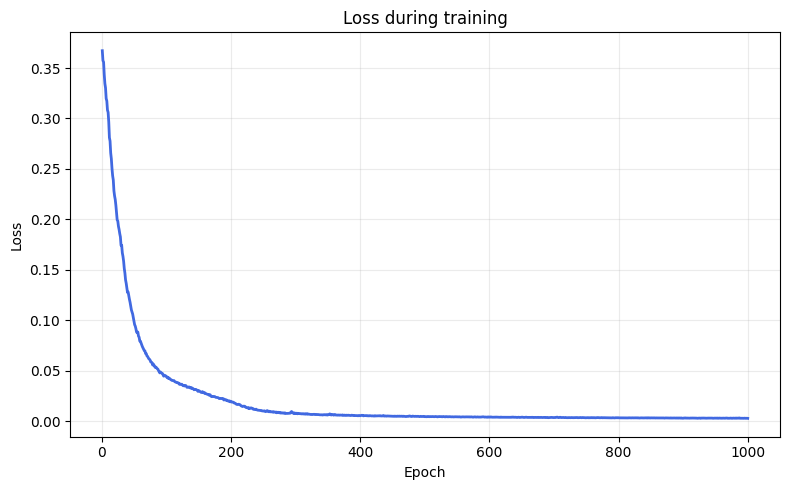

In [15]:
plot_loss(
    losses=losses,
    figsize=(8, 5),
    color="royalblue",
    line_width=2.0,
)

In [17]:
sample_id = 10
steps = 5

print(f"First {steps} predictions for sample number {sample_id}.")
print(f"Features:\n{features[sample_id][:steps]}")
print(f"Targets:\n{targets[sample_id][:steps]}")
print(f"Predictions:\n{predictions[sample_id][:steps]}")

First 5 predictions for sample number 10.
Features:
tensor([[ 0.0000,  0.0000],
        [-0.6710,  0.1377],
        [-0.6969,  0.7248],
        [-0.7439,  0.3751],
        [-0.6792,  0.1638]])
Targets:
tensor([[ 0.0000,  0.0000],
        [-0.6710,  0.1377],
        [-0.6928,  0.8624],
        [-0.7083,  1.2372],
        [-0.7049,  1.4010]], device='cuda:0')
Predictions:
tensor([[ 0.0020,  0.0756],
        [-0.7399,  0.1535],
        [-0.7575,  0.6669],
        [-0.7746,  1.1779],
        [-0.6926,  1.4921]], device='cuda:0', grad_fn=<SliceBackward0>)


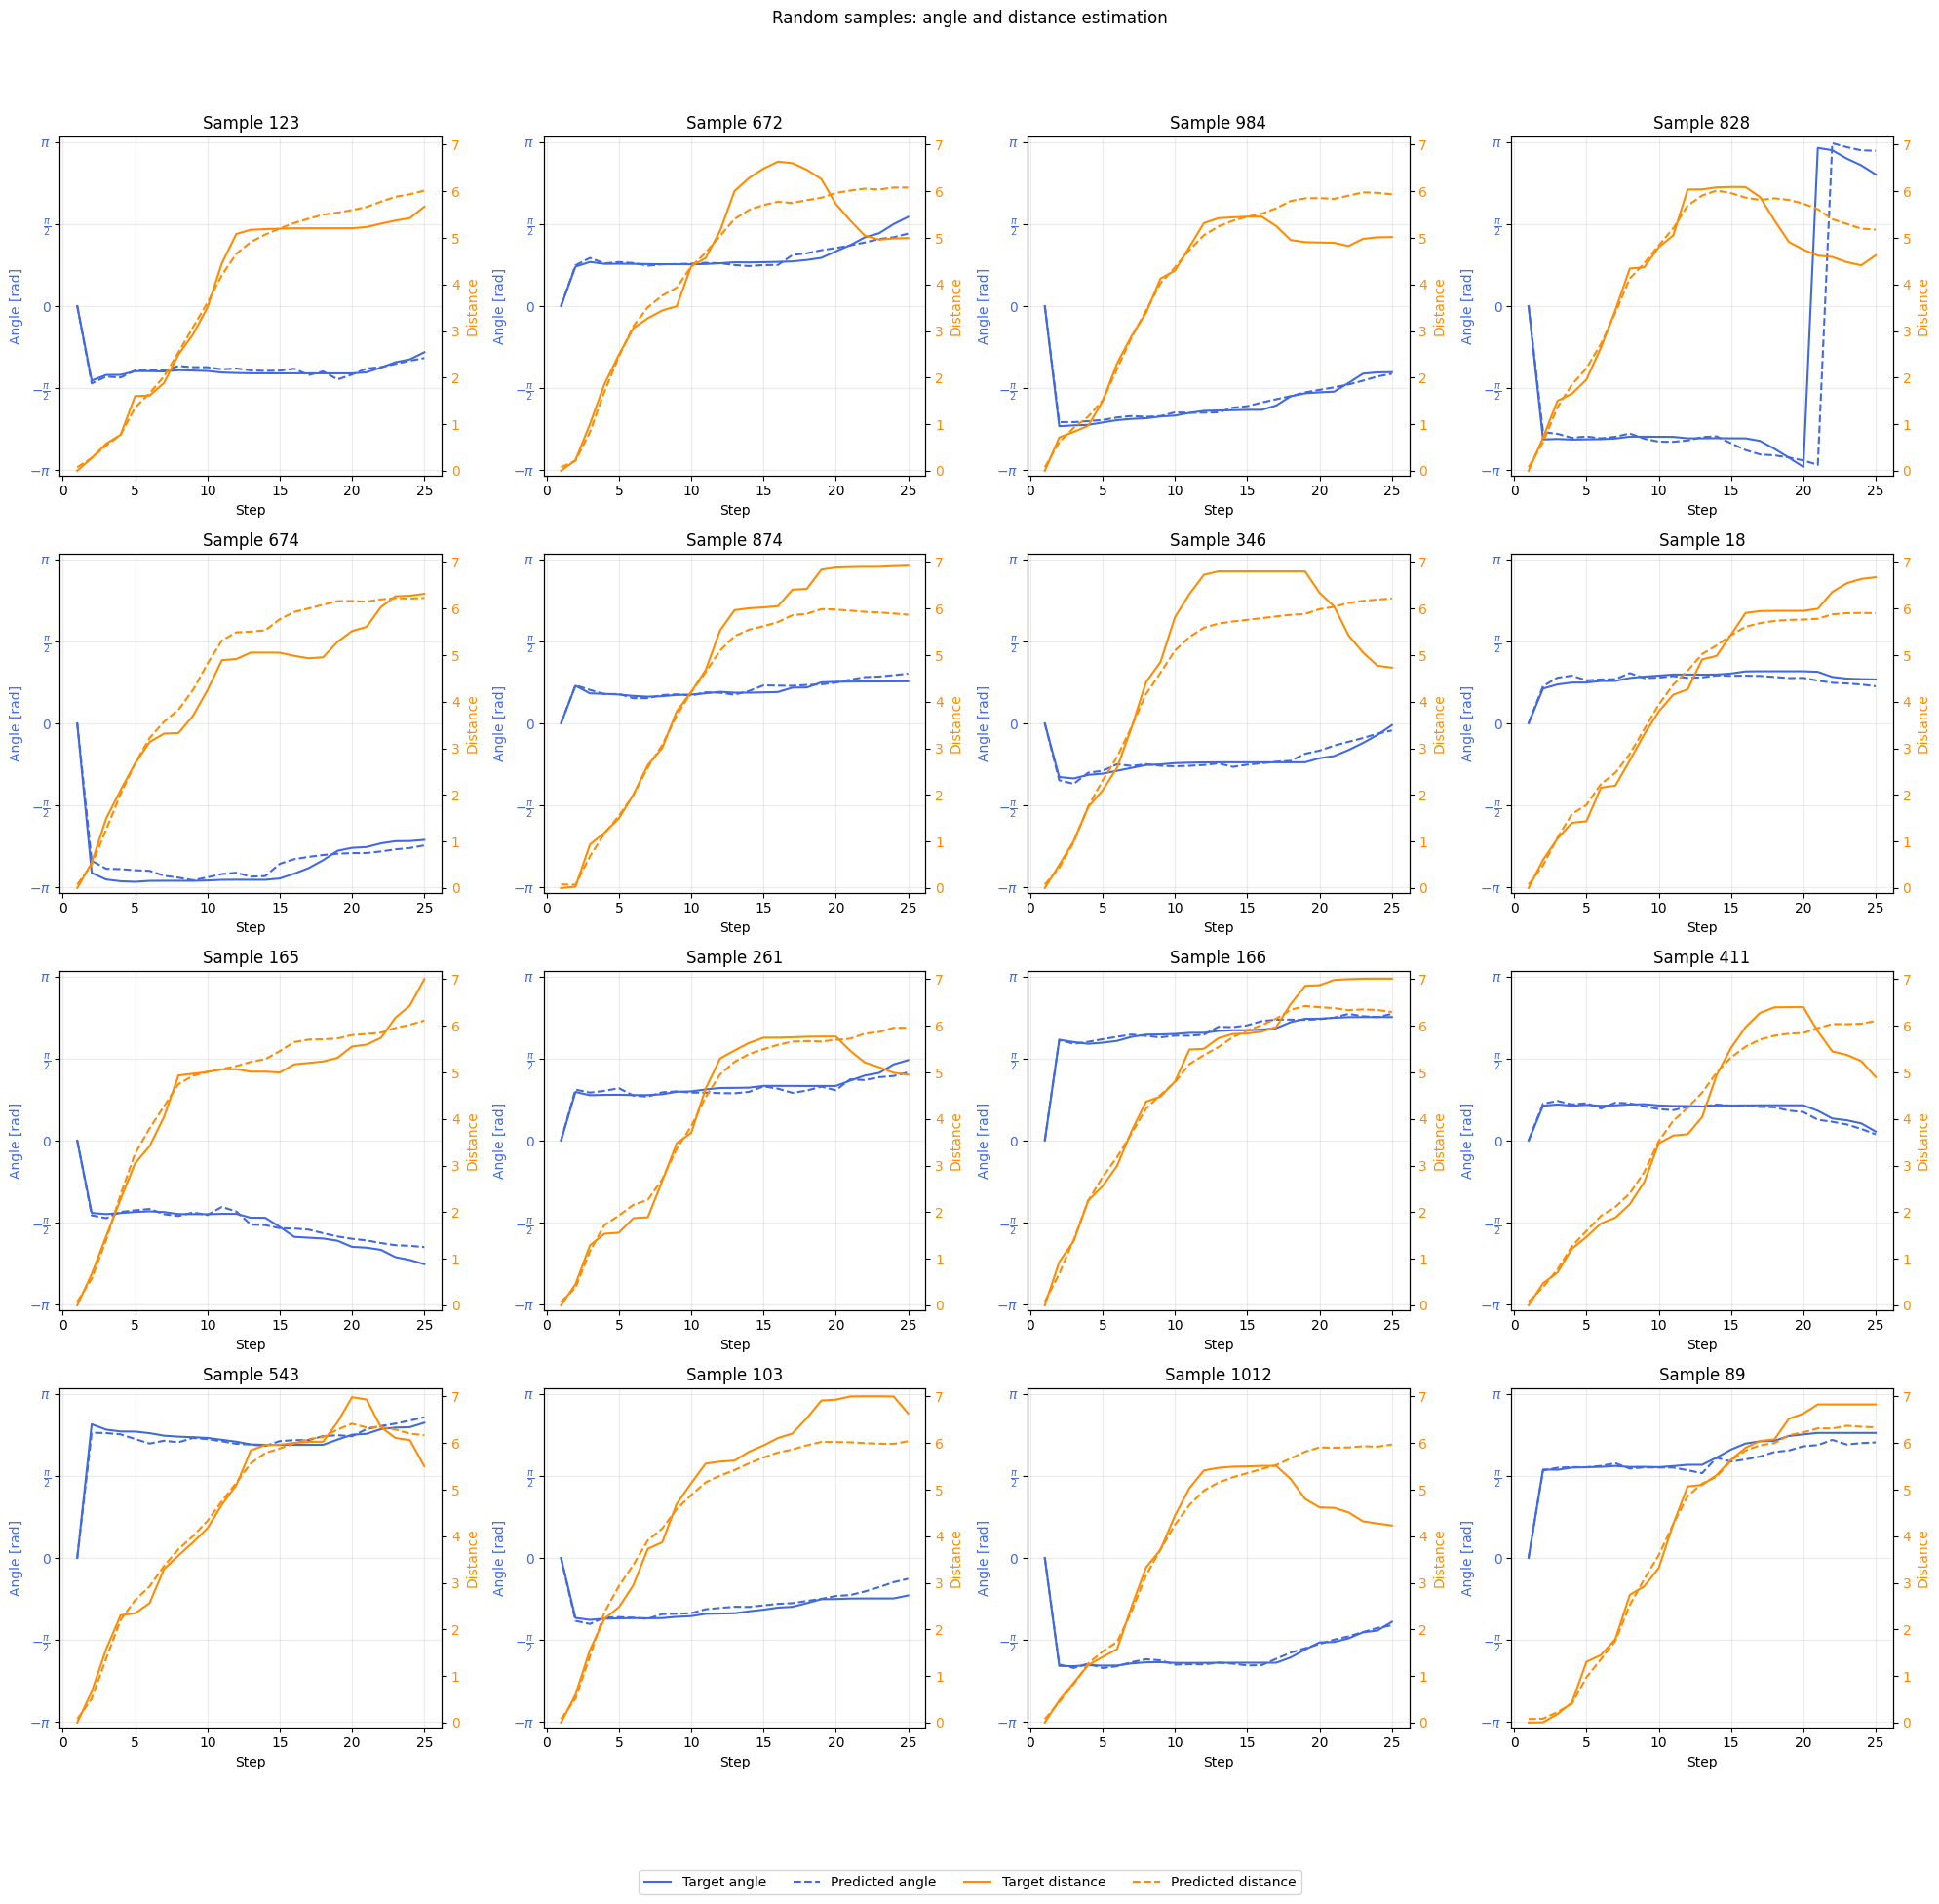

In [20]:
figure, axes, sample_ids = plot_random_samples(
    targets=targets,
    predictions=predictions,
    arena_size=arena_size,
    nrows=4,
    ncols=4,
    figsize=(20, 20),
    random_seed=44,
    angle_color="royalblue",
    distance_color="darkorange",
);